# Imports

In [15]:
import torch
import numpy as np
import torch.nn as nn
from os.path import join
from datetime import datetime

from trajectory_utils.waypoint import WayPoint 
from trajectory_utils.plotter import plot_trajectory_data, set_publication_style
from trajectory_utils.data import traj_data_dict_get, save_traj_data, load_traj_data

set_publication_style()

# Reproducibility

In [16]:
def set_seed(seed=42):
    """
    Set random seeds for reproducibility.

    Ensures deterministic behavior across:
        - CPU operations
        - GPU operations

    Args:
        seed (int): random seed
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# Dataset Construction

In [17]:
def build_bc_dataset_with_ids(TDList):
    """
    Construct dataset for imitation learning with demonstration identifiers.

    Each trajectory is converted into (state, velocity) pairs:
        x_t → x_dot_t ≈ (x_{t+1} - x_t) / dt

    Additionally tracks which demonstration each sample belongs to.

    Args:
        TDList (list of dict):
            Each dict contains:
                - 'states': (N, ≥3)
                - 't_steps': (N,)

    Returns:
        X (np.ndarray): (N_total, 3) states
        Y (np.ndarray): (N_total, 3) velocities
        demo_ids (np.ndarray): (N_total,) demo indices
    """
    X, Y, demo_ids = [], [], []
    
    for i, TD in enumerate(TDList):
        states = TD['states'][:, :3]
        t_steps = TD['t_steps']
        
        diffs = np.diff(states, axis=0)
        dt = np.diff(t_steps)
        x_dot = diffs / dt[:, None]
        
        X.append(states[:-1])
        Y.append(x_dot)
        demo_ids.append(np.full(len(states)-1, i))
    
    return np.vstack(X), np.vstack(Y), np.concatenate(demo_ids)

# ILEED Policy

In [18]:
class ILEEDPolicy(nn.Module):
    """
    ILEED Policy Network (Continuous Version - Eq. 3)

    This module implements the core components of the ILEED framework:
    
    1. Policy πθ(a | s):
       - Outputs a Gaussian distribution over actions:
            πθ(a | s) = N(μ(s), Σ(s))
       - Both mean μ(s) and covariance Σ(s) are functions of the state,
         parameterized by a neural network.

    2. Expertise Model ρ(s, i):
       - Estimates how reliable demonstrator 'i' is at state 's'
       - Defined as:
            ρ(s, i) = σ(⟨fϕ(s), ω_i⟩)
       - Where:
            fϕ(s) : state embedding
            ω_i   : embedding of demonstrator i

    3. Continuous ILEED Assumption (Paper Eq. 3):
       - Demonstrator actions are modeled as:
            a ~ N(μ(s), Σ(s) / ρ(s,i))
       - Lower ρ ⇒ higher variance ⇒ less trust in demonstrator

    Args:
        num_demos (int): Number of demonstrators (|D|)
        embed_dim (int): Dimension of embedding space for fϕ(s) and ω_i
    """

    def __init__(self, num_demos, embed_dim=16):
        super().__init__()
        
        hidden = 256
        
        # Policy Network Backbone (shared representation)
        # Maps state s → latent feature h(s)
        # Used to compute both μ(s) and σ(s)
        self.backbone = nn.Sequential(
            nn.Linear(3, hidden),
            nn.LayerNorm(hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )
        
        # Policy Heads        
        # Mean of Gaussian policy μ(s)
        self.mu_head = nn.Linear(hidden, 3)
        
        # Log standard deviation (for numerical stability)
        # σ(s) = exp(log_std(s))
        self.log_std_head = nn.Linear(hidden, 3)
        
        # State Embedding fϕ(s)
        # Maps state to embedding space used for expertise estimation
        self.state_encoder = nn.Sequential(
            nn.Linear(3, embed_dim),
            nn.SiLU()
        )
        
        # Demonstrator Embeddings ω_i
        # Learnable embedding per demonstrator
        self.demo_embed = nn.Embedding(num_demos, embed_dim)
        

    def forward(self, x, demo_id):
        """
        Forward pass.

        Args:
            x (Tensor): State tensor of shape (B, 3)
            demo_id (Tensor): Demonstrator indices (B,)

        Returns:
            mu  (Tensor): Mean action μ(s), shape (B, 3)
            std (Tensor): Standard deviation σ(s), shape (B, 3)
            rho (Tensor): Expertise score ρ(s,i), shape (B,)
        """

        # Policy Forward Pass
        h = self.backbone(x)
        
        mu = self.mu_head(h)                          # μ(s)
        
        # Clamp log_std for numerical stability
        log_std = self.log_std_head(h).clamp(-5, 2)
        std = torch.exp(log_std)                      # σ(s)

        # Expertise Computation
        # fϕ(s)
        s_feat = self.state_encoder(x)
        
        # ω_i
        d_feat = self.demo_embed(demo_id)
        
        # Dot-product → sigmoid → expertise score
        # ρ(s,i) = σ(⟨fϕ(s), ω_i⟩)
        rho = torch.sigmoid((s_feat * d_feat).sum(dim=-1))

        # Numerical Stability
        # Prevent ρ → 0 (which would cause variance → ∞ in Eq. 3)
        rho = torch.clamp(rho, min=0.1, max=1.0)

        return mu, std, rho

# ILEED Training

In [19]:
def ileed_loss(mu, std, rho, Y):
    """
    Continuous ILEED Negative Log-Likelihood (Eq. 3)

    Models demonstrator actions as:
        a ~ N(μ(s), Σ(s) / ρ(s,i))

    where:
        μ(s), Σ(s) : learned policy mean and covariance
        ρ(s,i)     : expertise of demonstrator i at state s

    Interpretation:
        - High ρ → low variance → strong trust in demonstrator
        - Low ρ → high variance → weak trust (noisy behavior)

    Args:
        mu  (Tensor): Mean μ(s), shape (B, D)
        std (Tensor): Std deviation σ(s), shape (B, D)
        rho (Tensor): Expertise ρ(s,i), shape (B,)
        Y   (Tensor): Demonstrated actions, shape (B, D)

    Returns:
        loss (Tensor): Scalar negative log-likelihood
    """

    # Prepare ρ
    # Expand to match action dimension
    rho = rho.unsqueeze(1)  # (B, 1)

    # Prevent numerical instability (ρ → 0 ⇒ variance → ∞)
    rho = torch.clamp(rho, min=0.1, max=1.0)

    # Variance Scaling (Eq. 3)
    # Σ_demo = Σ / ρ
    var = (std ** 2) / rho

    # Gaussian Log-Likelihood
    # log N(a; μ, Σ/ρ) =
    # -0.5 * [ (a-μ)^2 / var + log(var) + log(2π) ]
    log_prob = -0.5 * (
        ((Y - mu) ** 2) / var +
        torch.log(var) +
        np.log(2 * np.pi)
    )

    # Final Loss
    # Sum over dimensions, average over batch
    return -log_prob.sum(dim=1).mean()

In [20]:
def train_ileed_best(X, Y, demo_ids, num_demos, epochs, lr=1e-3, restarts=10):
    """
    Train ILEED policy using multiple random restarts (as done in the paper).

    This function jointly learns:
        - Policy parameters θ (μ(s), σ(s))
        - State embedding φ
        - Demonstrator embeddings ω_i

    Objective:
        Maximize likelihood under ILEED continuous model (Eq. 3):
            a ~ N(μ(s), Σ(s) / ρ(s,i))

    Strategy:
        - Normalize data
        - Train multiple models with different initializations
        - Select model with best final negative log-likelihood

    Args:
        X (np.ndarray): States (N, state_dim)
        Y (np.ndarray): Actions / velocities (N, action_dim)
        demo_ids (np.ndarray): Demonstrator indices (N,)
        num_demos (int): Number of unique demonstrators
        epochs (int): Training iterations per restart
        lr (float): Learning rate
        restarts (int): Number of random restarts

    Returns:
        best_model: Trained ILEED model
        x_mean, x_std: Normalization for inputs
        y_mean, y_std: Normalization for outputs
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Data Normalization
    # Important for stable neural network training
    x_mean, x_std = X.mean(0), X.std(0) + 1e-6
    y_mean, y_std = Y.mean(0), Y.std(0) + 1e-6

    Xn = (X - x_mean) / x_std
    Yn = (Y - y_mean) / y_std

    Xn = torch.tensor(Xn, dtype=torch.float32).to(device)
    Yn = torch.tensor(Yn, dtype=torch.float32).to(device)
    demo_ids = torch.tensor(demo_ids, dtype=torch.long).to(device)

    best_loss = float('inf')
    best_model = None

    # Multi-Restart Optimization (Paper detail)
    for r in range(restarts):
        print(f"\nRestart {r+1}/{restarts}")

        model = ILEEDPolicy(num_demos).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # Training Loop
        for epoch in range(epochs):

            # Forward pass
            mu, std, rho = model(Xn, demo_ids)

            # Core ILEED negative log-likelihood (Eq. 3)
            loss = ileed_loss(mu, std, rho, Yn)

            # Backprop
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (practical stability)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            if epoch % 50 == 0:
                print(f"[R{r}] Epoch {epoch}: NLL={loss.item():.4f}")

        # Model Selection (based on likelihood)
        with torch.no_grad():
            mu, std, rho = model(Xn, demo_ids)
            final_loss = ileed_loss(mu, std, rho, Yn).item()

        if final_loss < best_loss:
            best_loss = final_loss
            best_model = model

    print(f"\nBest Loss: {best_loss:.4f}")

    return best_model, x_mean, x_std, y_mean, y_std

# Rollout Simulation

In [21]:
def rollout_policy_normalized(
    model, x0,
    x_mean, x_std,
    y_mean, y_std,
    sim_duration, dt=1e-2
):
    """
    Simulate trajectory using trained ILEED policy.

    Uses mean prediction μ(x) for control:
        x_{t+1} = x_t + μ(x_t) * dt

    Args:
        model: trained ILEED model
        x0: initial state
        normalization parameters
        sim_duration: total time
        dt: timestep

    Returns:
        TD dictionary with trajectory
    """
    model.eval()
    device = next(model.parameters()).device
    
    x_mean_t = torch.tensor(x_mean, dtype=torch.float32, device=device)
    x_std_t  = torch.tensor(x_std,  dtype=torch.float32, device=device)
    y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
    y_std_t  = torch.tensor(y_std,  dtype=torch.float32, device=device)
    
    x = torch.tensor(x0, dtype=torch.float32, device=device)
    last_pos = x.detach().cpu().numpy()
    
    dummy_id = torch.tensor([0], device=device)
    
    TD = traj_data_dict_get()
    count = 1
    t = 0.0
    
    for _ in range(int(sim_duration / dt)):
        
        x_input = (x - x_mean_t) / x_std_t
        
        with torch.no_grad():
            mu, _, _ = model(x_input.unsqueeze(0), dummy_id)
            u = mu.squeeze(0)
            u = u * y_std_t + y_mean_t
        
        x = x + u * dt
        t += dt
        
        curr_pos = x.detach().cpu().numpy()
        curr_vel = np.linalg.norm((curr_pos - last_pos) / dt)
        last_pos = curr_pos.copy()
        
        if count % 5 == 0:
            TD['t_steps'].append(t)
            TD['states'].append(np.append(curr_pos, curr_vel))
            count = -1
        count += 1
    
    TD['states'] = np.array(TD['states'])
    TD['t_steps'] = np.array(TD['t_steps'])    
    return TD

# Set FILEDATE

In [22]:
FILEDATE = 'J'

# Load Trajectory Data

In [23]:
TDList_Demo = load_traj_data(
    join("data_dummy", f"TDList_Demo_{FILEDATE}.pkl")
)
num_demos = len(TDList_Demo)

[INFO]: Trajectory Data loaded succesfully -> data_dummy\TDList_Demo_J.pkl


# Preprocess & Train

In [34]:
X, Y, demo_ids = build_bc_dataset_with_ids(TDList_Demo)
model, x_mean, x_std, y_mean, y_std = train_ileed_best(X, Y, demo_ids, num_demos, epochs=50)


Restart 1/10
[R0] Epoch 0: NLL=4.6644

Restart 2/10
[R1] Epoch 0: NLL=4.9400

Restart 3/10
[R2] Epoch 0: NLL=4.7715

Restart 4/10
[R3] Epoch 0: NLL=4.9128

Restart 5/10
[R4] Epoch 0: NLL=4.7743

Restart 6/10
[R5] Epoch 0: NLL=4.9400

Restart 7/10
[R6] Epoch 0: NLL=4.6936

Restart 8/10
[R7] Epoch 0: NLL=4.8907

Restart 9/10
[R8] Epoch 0: NLL=4.7516

Restart 10/10
[R9] Epoch 0: NLL=4.5992

Best Loss: 2.8554


# Load Original Waypoints 

### This is used for comparison!

In [35]:
WP_og = WayPoint( 
    path_to_waypts=join("data_dummy", f"WayPoints_{FILEDATE}.txt"),
    waypoint_density=1000.,
    smoothness_params = np.full(2, 5e-4),
    waypoints_width=5e-2
)

# Evaluation Block

In [36]:
"""
Rollout evaluation:
- simulate trajectory
- compute deviation from reference waypoints
"""

t_end = np.median([TD['t_steps'][-1] for TD in TDList_Demo])
x0 = np.median([TD['states'][0, :3] for TD in TDList_Demo], axis=0)

TDList_Learnt = []
num_exps = 5

for i in range(num_exps):
    x0_ = x0 + np.random.random(x0.shape) * 1e-2
    TD = rollout_policy_normalized(
        model, x0_, x_mean, x_std,
        y_mean, y_std, sim_duration=t_end,
        dt=5e-3
    )
    progress, nearest_pts = WP_og.find_progress_value(TD['states'][:, :2])
    index = np.argmin(np.abs(progress - 1))
    
    TD['name'] = 'ILEED'
    TD['progress'] = progress[:index]
    TD['states'] = TD['states'][:index]
    TD['t_steps'] = TD['t_steps'][:index]
    TD['deviations'] = np.linalg.norm(TD['states'][:, :2] - nearest_pts[:index], axis=-1)
    TDList_Learnt.append(TD)

# Plot Trajectories

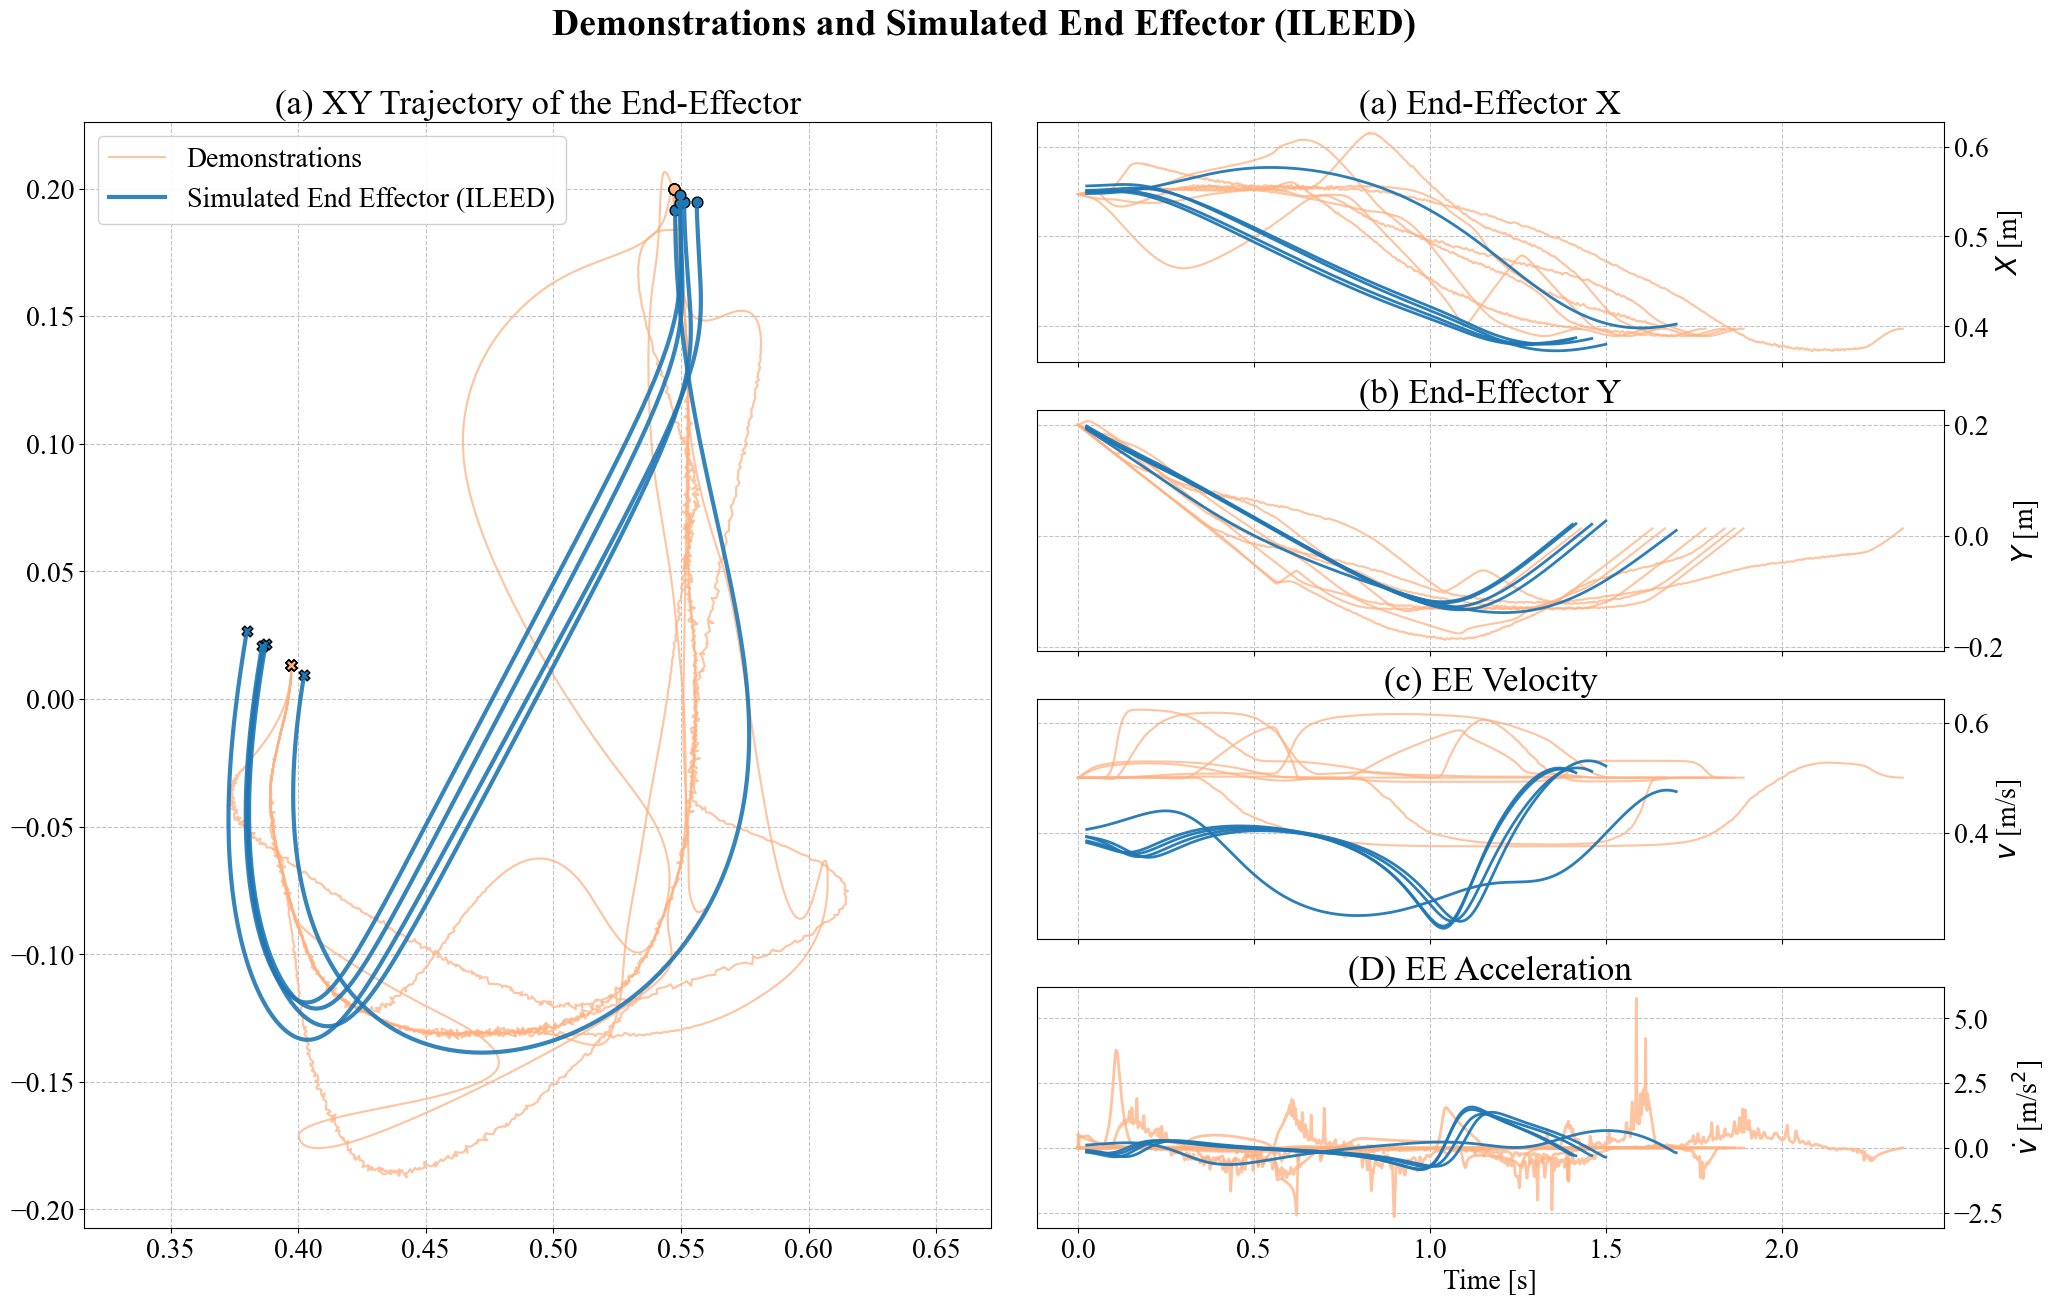

In [37]:
plot_trajectory_data(
    TDList_learnt=TDList_Learnt, 
    plot_state_dot_indices=[3],
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations",
    TD_learnt_name="Simulated End Effector (ILEED)", 
    filedate=f"{FILEDATE}_ILEED"
)

# Save Trajectory Data

In [38]:
save_traj_data(
    TDList=TDList_Learnt, 
    filepath=join("data_dummy", f"TDList_Learnt_{FILEDATE}_ILEED.pkl")
)

[INFO]: Trajectory Data saved succesfully -> data_dummy\TDList_Learnt_J_ILEED.pkl
